In [27]:
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

# Define your model
model = get_model("resnet18", weights=get_model_weights("resnet18").DEFAULT).eval()
# Set your CAM extractor
cam_extractor = LayerCAM(model)

In [ ]:
from torchvision.io import decode_image
from torchvision.models import get_model, get_model_weights
from torchcam.methods import LayerCAM

# Get a model and an image
weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights=weights).eval()
preprocess = weights.transforms()
img = decode_image("../data/Rottweiler_Dog.jpg")

input_tensor = preprocess(img)

with LayerCAM(model) as cam_extractor:
  out = model(input_tensor.unsqueeze(0))
  # Retrieve the CAM by passing the class index and the model output
  activation_map = cam_extractor(out.squeeze(0).argmax().item(), out)

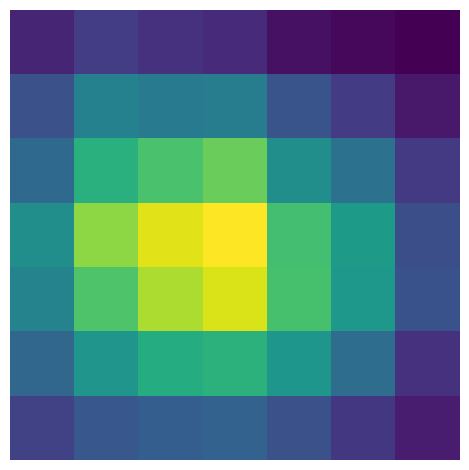

In [29]:
import matplotlib.pyplot as plt
# Visualize the raw CAM
plt.imshow(activation_map[0].squeeze(0).numpy()); plt.axis('off'); plt.tight_layout(); plt.show()

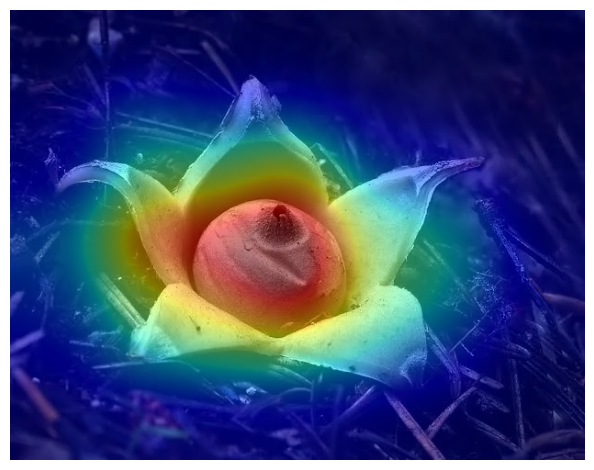

In [30]:
import matplotlib.pyplot as plt
from torchvision.transforms.v2.functional import to_pil_image
from torchcam.utils import overlay_mask

# Resize the CAM and overlay it
result = overlay_mask(to_pil_image(img), to_pil_image(activation_map[0].squeeze(0), mode='F'), alpha=0.5)
plt.imshow(result); plt.axis('off'); plt.tight_layout(); plt.show()

In [31]:

model.eval()
preprocess = weights.transforms()
batch = preprocess(img).unsqueeze(0)
prediction = model(batch).squeeze(0).softmax(0)


In [32]:
prediction.detach()

tensor([3.7201e-10, 2.1082e-11, 1.0756e-08, 7.0675e-09, 1.6252e-07, 7.4357e-09,
        8.4393e-09, 1.9419e-11, 1.0067e-10, 1.7090e-12, 1.9171e-10, 2.1576e-12,
        7.4671e-11, 5.3112e-10, 1.3964e-11, 1.4748e-10, 2.4812e-11, 9.4024e-11,
        1.2952e-11, 4.8628e-12, 2.1340e-08, 3.1801e-11, 2.3281e-11, 1.4784e-09,
        9.8589e-12, 2.8308e-11, 6.4902e-11, 1.2338e-10, 2.7766e-10, 1.8837e-09,
        6.4135e-10, 1.2532e-10, 8.9940e-10, 8.8726e-10, 3.5714e-10, 3.9571e-09,
        1.0031e-09, 1.1486e-10, 2.4327e-11, 1.1914e-11, 3.3543e-11, 1.8644e-11,
        1.8009e-12, 1.4731e-11, 6.6897e-12, 1.6735e-12, 8.7414e-12, 2.0525e-11,
        6.5381e-12, 4.2984e-12, 4.7799e-12, 8.6474e-11, 1.1844e-10, 3.1530e-11,
        7.5828e-11, 7.5114e-12, 6.1977e-12, 2.0938e-11, 1.1302e-11, 9.7965e-12,
        1.6503e-11, 2.4464e-10, 3.7048e-12, 1.7449e-10, 5.4440e-12, 3.5406e-12,
        5.2807e-11, 1.9740e-10, 9.9269e-12, 3.7709e-11, 4.5488e-12, 1.9798e-11,
        1.3510e-11, 2.7536e-11, 1.5745e-

Example of citation.<a name="cite_ref-1"></a>[[1]](#cite_note-1)




In [33]:
#> claude.ai
#> I have a json file with class names (imagenet_class_index.json) from 1000 classes in ImageNet and an output 
#  tensor from a ResNet18 (with default pretrained weights) softmax operation. 
#  Give a function that maps the maximum logit in the output tensor to the class name from the json file.

import json
import torch


def predict_class(output_tensor: torch.Tensor, class_index_path: str) -> dict:
    """
    Maps the maximum logit in a softmax output tensor to an ImageNet class name.

    Args:
        output_tensor:    1D or 2D tensor of shape (1000,) or (1, 1000),
                          typically the output of a softmax layer from ResNet18.
        class_index_path: Path to the imagenet_class_index.json file.

    Returns:
        A dict with keys:
            - 'class_index'  (int)   : index of the predicted class (0–999)
            - 'class_id'     (str)   : WordNet synset ID, e.g. "n01440764"
            - 'class_name'   (str)   : human-readable label, e.g. "tench"
            - 'confidence'   (float) : softmax probability of the top class
    """
    with open(class_index_path, "r") as f:
        class_index = json.load(f)  # keys are str "0".."999"

    # Flatten to 1-D in case the tensor has a batch dimension
    probs = output_tensor.squeeze()          # (1000,)
    if probs.ndim != 1 or probs.shape[0] != 1000:
        raise ValueError(
            f"Expected a tensor of 1000 values, got shape {tuple(output_tensor.shape)}"
        )

    top_idx = int(probs.argmax())            # index of highest probability
    synset_id, class_name = class_index[str(top_idx)]

    return {
        "class_index": top_idx,
        "class_id":    synset_id,
        "class_name":  class_name,
        "confidence":  float(probs[top_idx]),
    }

In [34]:

predict_class(prediction.detach(), "/home/raphael/Downloads/imagenet_class_index.json")

{'class_index': 995,
 'class_id': 'n13044778',
 'class_name': 'earthstar',
 'confidence': 0.9998127818107605}


<a name="cite_note-1"></a>1. [](#cite_ref-1) 
<pre>#> claude.ai
   I have a json file with class names (imagenet_class_index.json) from 1000 classes in ImageNet and an output 
   tensor from a ResNet18 (with default pretrained weights) softmax operation.  
   Give a function that maps the maximum logit in the output tensor to the class name from the json file.</pre>

